In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import matplotlib as mpl

import torch
import dnnlib.util_v7 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural_v7 import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"


# import matplotlib as mpl

# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Palatino", "Palatino Linotype", "Palatino LT STD", "TeX Gyre Pagella"],
#     "mathtext.fontset": "custom",
#     "mathtext.rm": "Palatino",
#     "mathtext.it": "Palatino:italic",
#     "mathtext.bf": "Palatino:bold",
# })



# 0. Some functions...

In [2]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title=None):
    # Plot True
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle(f'true, trial = {trial_idx}')
    plt.subplots_adjust(bottom=0.2)  # Make room for horizontal colorbar

    # Plot Simulated
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle(f'simulated- tau = {tau}')
    else:
        plt.suptitle(title)
    plt.subplots_adjust(bottom=0.2)

In [3]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [4]:
def recon_check_x0_allT(encoder, trial_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back.detach().cpu().numpy()

In [5]:
def mu_group_recon(bias,
                   loading_np: np.ndarray,
                   mu_all: np.ndarray,
                   mu_idx=None,             # int | list[int] | np.ndarray | slice | None
                   H: int = 28,
                   W: int = 28,
                   mean_img: np.ndarray = None,
                   clip=None):
    D = loading_np.shape[0]
    assert loading_np.ndim == 2
    K_load = loading_np.shape[1]          # number of latent dims in loading
    N, K_mu = mu_all.shape               # number of latent dims in mu_all
    assert H * W == D

    # normalize mu_idx to an integer index array IN LATENT SPACE
    if mu_idx is None:
        idx = np.arange(min(K_load, K_mu))
    elif isinstance(mu_idx, slice):
        idx = np.arange(min(K_load, K_mu))[mu_idx]
    else:
        arr = np.asarray(mu_idx)
        if arr.dtype == bool:
            idx = np.flatnonzero(arr)
        else:
            idx = arr.astype(int, copy=False).ravel()

    # sanity: all requested dims must exist in both loading and mu_all
    max_idx = int(idx.max()) if idx.size > 0 else -1
    assert max_idx < K_load, f"mu_idx uses dim {max_idx}, but loading has only {K_load} cols"
    assert max_idx < K_mu,   f"mu_idx uses dim {max_idx}, but mu_all has only {K_mu} cols"

    A_sub  = loading_np[:, idx]     # (D, K_sel)
    mu_sub = mu_all[:, idx]         # (N, K_sel)
    recon_flat = mu_sub @ A_sub.T   # (N, D)

    if mean_img is not None:
        mean_flat = mean_img.reshape(-1)
        assert mean_flat.size == D
        recon_flat = recon_flat + mean_flat

    recon_flat = recon_flat + bias
    recon = recon_flat.reshape(N, H, W)
    if clip is not None:
        lo, hi = clip
        recon = np.clip(recon, lo, hi)
    return recon


In [6]:
def plot_mu_velocity_2d(
    mu,
    v_mu,
    trajectories=None,
    dims_2d=(0, 1),
    title=None,
    arrow_frac=0.05,
    arrow_size=1.2,
    linewidth=1.5,
    traj_alpha=0.4,
    traj_width=0.8,
    traj_color="gray",
    max_trajs=300,
    quiver_alpha=0.6,
    max_points=3000,
    figsize=(7, 6),
    speed_color=None,                      # NEW
    colorbar_label=r"$\|\dot{\mu}\|$",     # NEW
):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    ax.grid(False)

    traj_list = []
    if trajectories is not None:
        traj_source = trajectories
        for i, traj in enumerate(traj_source):
            if i >= max_trajs:
                break
            t_np = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.array(traj)
            traj_list.append(t_np)

    d1, d2 = dims_2d
    for t_np in traj_list:
        ax.plot(
            t_np[:, d1], t_np[:, d2],
            color=traj_color, alpha=traj_alpha, linewidth=traj_width, zorder=1
        )

    coords = mu[:, [d1, d2]]
    vecs   = v_mu[:, [d1, d2]]
    N = coords.shape[0]

    # speed_color preprocessing
    if speed_color is not None:
        speed_color = speed_color.detach().cpu().numpy() if hasattr(speed_color, "detach") else np.asarray(speed_color)
        speed_color = np.asarray(speed_color).reshape(-1)
        assert speed_color.shape[0] == mu.shape[0]

    if max_points is not None and N > max_points:
        idx = np.random.choice(N, size=max_points, replace=False)
        coords_2d = coords[idx]
        vecs_2d   = vecs[idx]
        speed_c   = speed_color[idx] if speed_color is not None else None
    else:
        coords_2d = coords
        vecs_2d   = vecs
        speed_c   = speed_color if speed_color is not None else None

    speed_proj = np.linalg.norm(vecs_2d, axis=1)
    eps = 1e-8
    dirs = vecs_2d / (speed_proj[:, None] + eps)

    x_min, x_max = coords_2d[:, 0].min(), coords_2d[:, 0].max()
    y_min, y_max = coords_2d[:, 1].min(), coords_2d[:, 1].max()
    span = max(x_max - x_min, y_max - y_min) + eps
    L = arrow_frac * span
    U = dirs[:, 0] * L
    V = dirs[:, 1] * L

    base_width = 0.004
    base_headwidth = 4.0
    base_headlength = 6.0
    base_headaxislength = 5.0
    width = base_width * arrow_size

    # coloring values
    if speed_c is None:
        speed_c = speed_proj

    norm = Normalize(vmin=float(speed_c.min()), vmax=float(speed_c.max()))
    q = ax.quiver(
        coords_2d[:, 0], coords_2d[:, 1], U, V, speed_c,
        cmap=cm.viridis, norm=norm, angles="xy", scale_units="xy", scale=1.0,
        width=width,
        headwidth=base_headwidth * arrow_size,
        headlength=base_headlength * arrow_size,
        headaxislength=base_headaxislength * arrow_size,
        linewidth=linewidth, alpha=quiver_alpha, zorder=2
    )
    cb = fig.colorbar(q, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(colorbar_label)

    ax.set_xlabel(fr"$\mu_{{{d1+1}}}$")
    ax.set_ylabel(fr"$\mu_{{{d2+1}}}$")
    if title:
        ax.set_title(title)
    ax.axis("equal")

    return fig, ax, q


def plot_mu_velocity_3d(
    mu,
    v_mu,
    trajectories=None,
    dims_3d=(0, 1, 2),
    title=None,
    arrow_frac=0.1,
    arrow_size=1.5,
    linewidth=1.5,
    base_arrow_length_ratio=0.3,
    traj_alpha=0.4,
    traj_width=0.8,
    quiver_alpha=0.6,
    traj_color="gray",
    max_trajs=300,
    max_points=3000,
    figsize=(10, 7),
    elev=None,
    azim=None,
    roll=None,
    speed_norm=None,
    speed_color=None,                      # NEW
    colorbar_label=r"$\|\dot{\mu}\|$",     # NEW
):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection="3d")
    ax.set_box_aspect((1, 1, 1))
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor((1, 1, 1, 0))
        axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        axis._axinfo["grid"]["linewidth"] = 0

    traj_list = []
    if trajectories is not None:
        traj_source = trajectories
        for i, traj in enumerate(traj_source):
            if i >= max_trajs:
                break
            t_np = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.array(traj)
            traj_list.append(t_np)

    d1, d2, d3 = dims_3d
    for t_np in traj_list:
        ax.plot(
            t_np[:, d1], t_np[:, d2], t_np[:, d3],
            color=traj_color, alpha=traj_alpha, linewidth=traj_width, zorder=1
        )

    coords = mu[:, [d1, d2, d3]]
    vecs   = v_mu[:, [d1, d2, d3]]
    N = coords.shape[0]

    # speed_color preprocessing
    if speed_color is not None:
        speed_color = speed_color.detach().cpu().numpy() if hasattr(speed_color, "detach") else np.asarray(speed_color)
        speed_color = np.asarray(speed_color).reshape(-1)
        assert speed_color.shape[0] == mu.shape[0]

    if max_points is not None and N > max_points:
        idx = np.random.choice(N, size=max_points, replace=False)
        coords_3d = coords[idx]
        vecs_3d   = vecs[idx]
        speed_c   = speed_color[idx] if speed_color is not None else None
    else:
        coords_3d = coords
        vecs_3d   = vecs
        speed_c   = speed_color if speed_color is not None else None

    speed_proj = np.linalg.norm(vecs_3d, axis=1)
    eps = 1e-8
    dirs = vecs_3d / (speed_proj[:, None] + eps)

    mins = coords_3d.min(axis=0)
    maxs = coords_3d.max(axis=0)
    span = float(np.max(maxs - mins) + eps)

    L = arrow_frac * span
    U, V, W = dirs[:, 0], dirs[:, 1], dirs[:, 2]

    # coloring values
    if speed_c is None:
        speed_c = speed_proj

    norm = speed_norm if speed_norm is not None else Normalize(
        vmin=float(speed_c.min()),
        vmax=float(speed_c.max()),
    )
    colors = cm.viridis(norm(speed_c))
    colors[:, 3] = quiver_alpha

    ax.quiver(
        coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2],
        U, V, W,
        length=L, normalize=False, colors=colors,
        linewidth=linewidth * arrow_size,
        arrow_length_ratio=base_arrow_length_ratio * arrow_size,
        zorder=2
    )

    mappable = cm.ScalarMappable(norm=norm, cmap="viridis")
    mappable.set_array(speed_c)
    cb = fig.colorbar(mappable, ax=ax, fraction=0.035, pad=0.08)
    cb.set_label(colorbar_label)

    ax.set_xlabel(fr"$\mu_{{{d1+1}}}$")
    ax.set_ylabel(fr"$\mu_{{{d2+1}}}$")
    ax.set_zlabel(fr"$\mu_{{{d3+1}}}$")
    if title:
        ax.set_title(title)

    if (elev is not None) or (azim is not None) or (roll is not None):
        try:
            ax.view_init(elev=elev, azim=azim, roll=roll)
        except TypeError:
            ax.view_init(elev=elev, azim=azim)

    return fig, ax

In [7]:
def plot_frame_compact(
    rows,                 # list like [dset_samples, out_imgs_tau0_flow, ...]
    trial_idx,
    idxs,                 # 1D int array, columns
    row_labels=None,      # list of strings, one per row
    mean_img=None,
    figsize=(6, 2.6),
    img_cmap="gray",
    vmin=None,
    vmax=None,
    border_from=None,
    border_lw=3.0,
    left=0.10, right=0.99, bottom=0.05, top=0.95,
    wspace=0.02, hspace=0.02,
):
    import numpy as np
    import matplotlib.pyplot as plt

    idxs = np.asarray(idxs).astype(int)
    n_rows = len(rows)
    n_cols = len(idxs)

    # --- global vmin/vmax (consistent across rows) ---
    if vmin is None or vmax is None:
        mn, mx = np.inf, -np.inf
        for data in rows:
            X = data[trial_idx]  # [T, 1, H, W] (torch or np)
            for i in idxs:
                img = X[i, 0]
                if hasattr(img, "detach"):
                    img = img.detach().cpu().numpy()
                else:
                    img = np.asarray(img)
                if mean_img is not None:
                    img = img + mean_img
                mn = min(mn, float(img.min()))
                mx = max(mx, float(img.max()))
        if vmin is None: vmin = mn
        if vmax is None: vmax = mx

    if border_from is not None:
        cmap = border_from.get_cmap()
        norm = border_from.norm
        col_colors = cmap(norm(idxs.astype(float)))
    else:
        col_colors = ["k"] * n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)

    for r, data in enumerate(rows):
        X = data[trial_idx]
        for c, i in enumerate(idxs):
            ax = axes[r, c]

            img = X[i, 0]
            if hasattr(img, "detach"):
                img = img.detach().cpu().numpy()
            else:
                img = np.asarray(img)
            if mean_img is not None:
                img = img + mean_img

            ax.imshow(img, cmap=img_cmap, vmin=vmin, vmax=vmax)

            # keep spines for colored border, so don't ax.axis("off")
            ax.set_xticks([]); ax.set_yticks([])

            # titles only on first row
            if r == 0:
                ax.set_title(f"t={i}")
            else:
                ax.set_title("")

            # colored border per column
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(border_lw)
                sp.set_color(col_colors[c])

    # row labels on the left, centered per row (compact)
    if row_labels is not None:
        for r, lab in enumerate(row_labels):
            pos = axes[r, 0].get_position()
            y = 0.5 * (pos.y0 + pos.y1)
            x = pos.x0 - 0.02
            fig.text(x, y, lab, ha="right", va="center")

    return fig, axes

# 1. Read Data

In [8]:
folder_data = 'out/ball/t_detach/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [9]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [10]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

In [11]:
TRIAL_IDX = 0
T = T_max

In [12]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
data_flattent_all = np.concatenate(data_flattent, axis=0)

# 2. Read Models

In [13]:
folder_ref = 'out/ball/t_detach/00000-ball_dim50_lag0_none-prr-uncond-regularFM-gpus1-batch256-fp32'
folder1 = 'out/ball/t_detach/00000-ball_dim50_lag0_none-prr-uncond-regularFM-gpus1-batch256-fp32'
folder2 = 'out/ball/t_detach/00017-ball_dim50_lag0_none_5_1_1-prr-uncond-regularFM-gpus1-batch256-fp32'
folder3 = 'out/ball/t_detach/00015-ball_dim50_lag0_none_1_5_1-prr-uncond-regularFM-gpus1-batch256-fp32'
folder4 = 'out/ball/t_detach/00016-ball_dim50_lag0_none_1_1_5-prr-uncond-regularFM-gpus1-batch256-fp32'

_, _, encoder_ref, _ = read_model(folder_ref, '/network-snapshot-004264.pkl')

flow_net1, dyn_net1, encoder1, lag = read_model(folder1, '/network-snapshot-004264.pkl')
flow_net2, dyn_net2, encoder2, lag = read_model(folder2, '/network-snapshot-004264.pkl')
flow_net3, dyn_net3, encoder3, lag = read_model(folder3, '/network-snapshot-004264.pkl')
flow_net4, dyn_net4, encoder4, lag = read_model(folder4, '/network-snapshot-004264.pkl')

apply_posthoc_alignment(encoder1, encoder_ref)
apply_posthoc_alignment(encoder2, encoder_ref)
apply_posthoc_alignment(encoder3, encoder_ref)
apply_posthoc_alignment(encoder4, encoder_ref)

Aligning signs for 0 columns.
Target encoder successfully patched.
Aligning signs for 108 columns.
Target encoder successfully patched.
Aligning signs for 97 columns.
Target encoder successfully patched.
Aligning signs for 93 columns.
Target encoder successfully patched.


In [14]:
dim_to_keep = 3
_, d1, _, _, _ = latent_mu(dset_samples, encoder1.to(device), dim_to_keep, device, fullRes = True); d1_np = d1.detach().cpu().numpy()
_, d2, _, _, _ = latent_mu(dset_samples, encoder2.to(device), dim_to_keep, device, fullRes = True); d2_np = d2.detach().cpu().numpy()
_, d3, _, _, _ = latent_mu(dset_samples, encoder3.to(device), dim_to_keep, device, fullRes = True); d3_np = d3.detach().cpu().numpy()
_, d4, _, _, _ = latent_mu(dset_samples, encoder4.to(device), dim_to_keep, device, fullRes = True); d4_np = d4.detach().cpu().numpy()



In [15]:
k_max = 200
k_target = 50

cum_energy1 = np.cumsum(d1_np); K_eff1 = 1 + np.searchsorted(cum_energy1, 0.95 * cum_energy1[-1])
cum_energy2 = np.cumsum(d2_np); K_eff2 = 1 + np.searchsorted(cum_energy2, 0.95 * cum_energy2[-1])
cum_energy3 = np.cumsum(d3_np); K_eff3 = 1 + np.searchsorted(cum_energy3, 0.95 * cum_energy3[-1])
cum_energy4 = np.cumsum(d4_np); K_eff4 = 1 + np.searchsorted(cum_energy4, 0.95 * cum_energy4[-1])

In [16]:
print([K_eff1, K_eff2, K_eff3, K_eff4])

[np.int64(30), np.int64(29), np.int64(29), np.int64(29)]


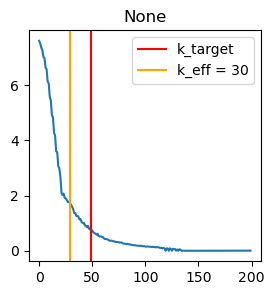

In [17]:
fig = plt.figure(figsize=(3, 3))
plt.plot(np.sqrt(d1_np[0:k_max]))
plt.axvline(x=k_target-1, color='red', label = 'k_target')
plt.axvline(x=K_eff1-1, color='orange', label = 'k_eff = ' + str(K_eff1))
plt.title('None');
plt.legend()

In [18]:
tau = 0.0
n_step = T_max

traj_sim_tau0_flattent1, _ = generate_traj_image_onthefly(dyn_net1.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net1.to(device),
                                                         clamp_range=clamp_range
                                                         )

traj_sim_tau0_flattent2, _ = generate_traj_image_onthefly(dyn_net2.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net2.to(device),
                                                         clamp_range=clamp_range
                                                         )

traj_sim_tau0_flattent3, _ = generate_traj_image_onthefly(dyn_net3.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net3.to(device),
                                                         clamp_range=clamp_range
                                                         )

traj_sim_tau0_flattent4, _ = generate_traj_image_onthefly(dyn_net4.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net4.to(device),
                                                         clamp_range=clamp_range
                                                         )

100%|███████████████████████████████████████████| 49/49 [00:05<00:00,  8.51it/s]


# Plot

In [19]:
plotFolder = "paper_fig/ball/app_weight"

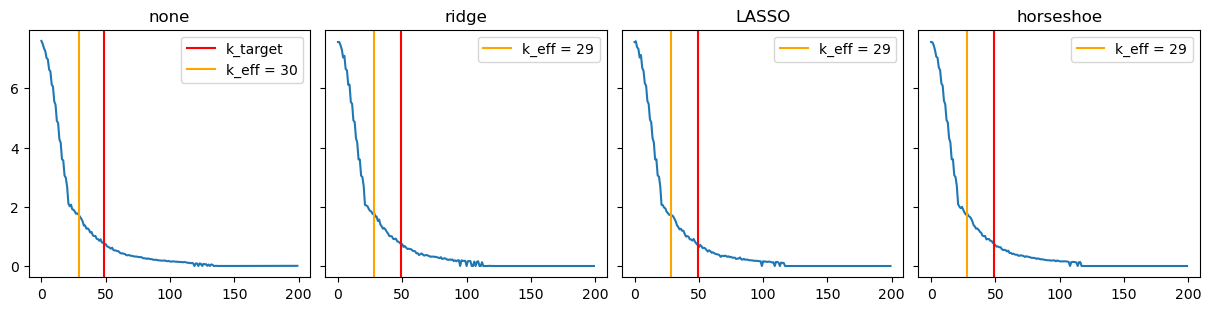

In [20]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True, sharey=True)


axs[0].plot(np.sqrt(d1_np[0:k_max]))
axs[0].axvline(x=k_target-1, color="red", label="k_target")
axs[0].axvline(x=K_eff1-1, color="orange", label=f"k_eff = {K_eff1}")
axs[0].set_title("none")
axs[0].legend()

axs[1].plot(np.sqrt(d2_np[0:k_max]))
axs[1].axvline(x=k_target-1, color="red")
axs[1].axvline(x=K_eff2-1, color="orange", label=f"k_eff = {K_eff2}")
axs[1].set_title("ridge")
axs[1].legend()

axs[2].plot(np.sqrt(d3_np[0:k_max]))
axs[2].axvline(x=k_target-1, color="red")
axs[2].axvline(x=K_eff3-1, color="orange", label=f"k_eff = {K_eff3}")
axs[2].set_title("LASSO")
axs[2].legend()

axs[3].plot(np.sqrt(d4_np[0:k_max]))
axs[3].axvline(x=k_target-1, color="red")
axs[3].axvline(x=K_eff4-1, color="orange", label=f"k_eff = {K_eff4}")
axs[3].set_title("horseshoe")
axs[3].legend()

ymin = min(ax.get_ylim()[0] for ax in axs)
ymax = max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(ymin, ymax)

plt.savefig(plotFolder + "/1_sqrt_d.pdf")
plt.savefig(plotFolder + "/1_sqrt_d.png")

In [21]:
mu_traj_sim1, _, _, _, _ = latent_mu(traj_sim_tau0_flattent1,
                                    encoder1.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim2, _, _, _, _ = latent_mu(traj_sim_tau0_flattent2,
                                    encoder2.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim3, _, _, _, _ = latent_mu(traj_sim_tau0_flattent3,
                                    encoder3.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim4, _, _, _, _ = latent_mu(traj_sim_tau0_flattent4,
                                    encoder4.to(device), dim_to_keep, device, fullRes = True)

mu_traj_sim1_np = [mu_traj_sim1[j].cpu().numpy() for j in range(len(mu_traj_sim1))]
mu_traj_sim2_np = [mu_traj_sim2[j].cpu().numpy() for j in range(len(mu_traj_sim2))]
mu_traj_sim3_np = [mu_traj_sim3[j].cpu().numpy() for j in range(len(mu_traj_sim3))]
mu_traj_sim4_np = [mu_traj_sim4[j].cpu().numpy() for j in range(len(mu_traj_sim4))]

In [22]:
mu_pts_sim1, v_mu_sim1, v_mu_full_sim1 = compute_mu_velocity_field(
    latent_traj_list=traj_sim_tau0_flattent1,
    dyn_net=dyn_net1,
    encoder=encoder1,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

In [23]:
mu_pts_sim2, v_mu_sim2, v_mu_full_sim2 = compute_mu_velocity_field(
    latent_traj_list=traj_sim_tau0_flattent2,
    dyn_net=dyn_net2,
    encoder=encoder2,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

In [24]:
mu_pts_sim3, v_mu_sim3, v_mu_full_sim3 = compute_mu_velocity_field(
    latent_traj_list=traj_sim_tau0_flattent3,
    dyn_net=dyn_net3,
    encoder=encoder3,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

In [25]:
mu_pts_sim4, v_mu_sim4, v_mu_full_sim4 = compute_mu_velocity_field(
    latent_traj_list=traj_sim_tau0_flattent4,
    dyn_net=dyn_net4,
    encoder=encoder4,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

In [26]:
dim_to_keep = 3
latent_traj_list_1 = proj_to_latent(dset_samples, flow_net1.to(device), 0.0, device)
latent_traj_list_2 = proj_to_latent(dset_samples, flow_net2.to(device), 0.0, device)
latent_traj_list_3 = proj_to_latent(dset_samples, flow_net3.to(device), 0.0, device)
latent_traj_list_4 = proj_to_latent(dset_samples, flow_net4.to(device), 0.0, device)

mu_traj_flow1, _, _, _, _ = latent_mu(latent_traj_list_1, encoder1.to(device),
                                      dim_to_keep, device,
                                      fullRes = True, resid_tol=1e-15)
mu_traj_flow2, _, _, _, _ = latent_mu(latent_traj_list_2, encoder2.to(device),
                                      dim_to_keep, device,
                                      fullRes = True, resid_tol=1e-15)
mu_traj_flow3, _, _, _, _ = latent_mu(latent_traj_list_3, encoder3.to(device),
                                      dim_to_keep, device,
                                      fullRes = True, resid_tol=1e-15)
mu_traj_flow4, _, _, _, _ = latent_mu(latent_traj_list_4, encoder4.to(device),
                                      dim_to_keep, device,
                                      fullRes = True, resid_tol=1e-15)


mu_traj_flow1_np = [mu_traj_flow1[j].cpu().numpy() for j in range(len(mu_traj_flow1))]
mu_traj_flow2_np = [mu_traj_flow2[j].cpu().numpy() for j in range(len(mu_traj_flow2))]
mu_traj_flow3_np = [mu_traj_flow3[j].cpu().numpy() for j in range(len(mu_traj_flow3))]
mu_traj_flow4_np = [mu_traj_flow4[j].cpu().numpy() for j in range(len(mu_traj_flow4))]

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 12.41it/s]


In [27]:
mu_pts_flow1, v_mu_flow1, v_mu_full_flow1 = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list_1,
    dyn_net=dyn_net1,
    encoder=encoder1,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

mu_pts_flow2, v_mu_flow2, v_mu_full_flow2 = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list_2,
    dyn_net=dyn_net2,
    encoder=encoder2,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

mu_pts_flow3, v_mu_flow3, v_mu_full_flow3 = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list_3,
    dyn_net=dyn_net3,
    encoder=encoder3,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

mu_pts_flow4, v_mu_flow4, v_mu_full_flow4 = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list_4,
    dyn_net=dyn_net4,
    encoder=encoder4,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
    return_full=True
)

In [28]:
d1, d2, d3 = (0, 1, 2)

all_mu = np.concatenate([
    np.asarray(mu_pts_sim1)[:, [d1, d2, d3]],
    np.asarray(mu_pts_sim2)[:, [d1, d2, d3]],
    np.asarray(mu_pts_sim3)[:, [d1, d2, d3]],
    np.asarray(mu_pts_sim4)[:, [d1, d2, d3]],
], axis=0)

mins = all_mu.min(axis=0)
maxs = all_mu.max(axis=0)
pad  = 0.02 * (maxs - mins + 1e-8)

xlim = (mins[0] - pad[0], maxs[0] + pad[0])
ylim = (mins[1] - pad[1], maxs[1] + pad[1])
zlim = (mins[2] - pad[2], maxs[2] + pad[2])


elev=20
azim=-140

view = dict(elev=elev, azim=azim)  # pick whatever you like, but keep it fixed


# d1, d2, d3 = dims

all_speed_colors_raw = [
    v_mu_full_sim1, v_mu_full_sim2, v_mu_full_sim3, v_mu_full_sim4,
    v_mu_full_flow1, v_mu_full_flow2, v_mu_full_flow3, v_mu_full_flow4,
]

all_speed_colors = []
for sc in all_speed_colors_raw:
    sc = sc.detach().cpu().numpy() if hasattr(sc, "detach") else np.asarray(sc)

    # if user accidentally passes full velocity vectors (N, D_full), convert to norm (N,)
    if sc.ndim == 2:
        sc = np.linalg.norm(sc, axis=1)

    sc = np.asarray(sc).reshape(-1)
    all_speed_colors.append(sc)

vmin = float(min(s.min() for s in all_speed_colors))
vmax = float(max(s.max() for s in all_speed_colors))
shared_norm = Normalize(vmin=vmin, vmax=vmax)


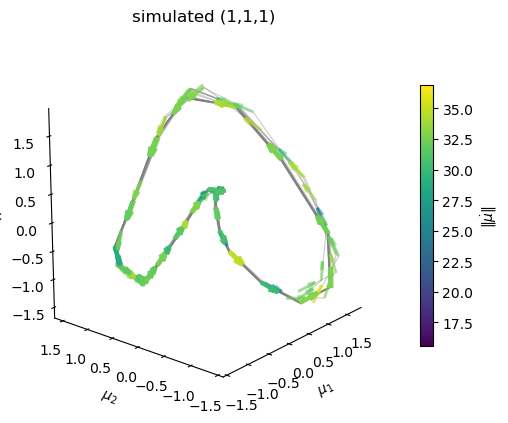

In [29]:
fig, ax = plot_mu_velocity_3d(mu_pts_sim1, v_mu_sim1, trajectories=mu_traj_sim1_np,
                              speed_color=v_mu_full_sim1,
                              dims_3d=(0,1,2), title="simulated (1,1,1)",
                              figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/2_1_sim_v_3d_111.pdf")
plt.savefig(plotFolder + "/2_1_sim_v_3d_111.png")

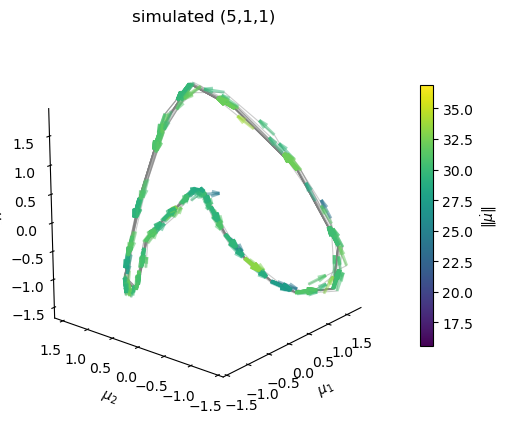

In [30]:
fig, ax = plot_mu_velocity_3d(mu_pts_sim2, v_mu_sim2,
                    speed_color=v_mu_full_sim2,
                    trajectories=mu_traj_sim2_np, dims_3d=(0,1,2),
                    title="simulated (5,1,1)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/2_2_sim_v_3d_511.pdf")
plt.savefig(plotFolder + "/2_2_sim_v_3d_511.png")

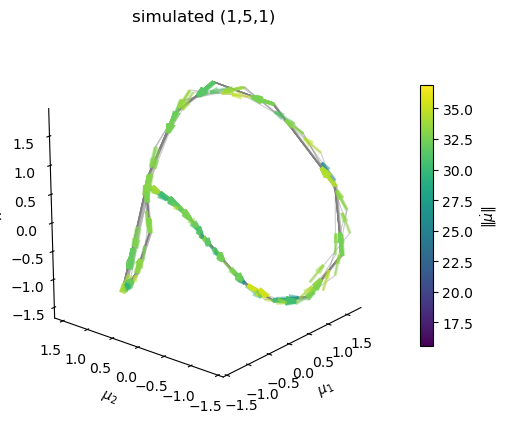

In [31]:
fig, ax = plot_mu_velocity_3d(mu_pts_sim3, v_mu_sim3, trajectories=mu_traj_sim3_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_sim3,
                    title="simulated (1,5,1)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/2_3_sim_v_3d_151.pdf")
plt.savefig(plotFolder + "/2_3_sim_v_3d_151.png")

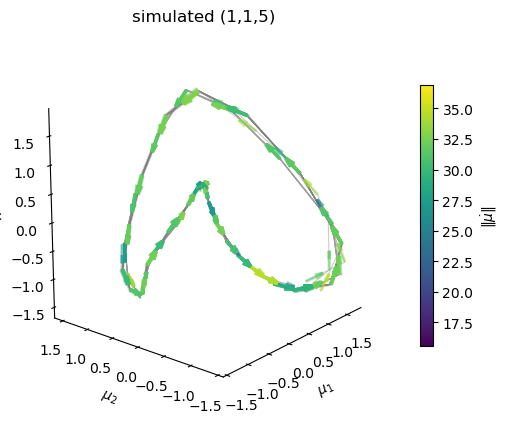

In [32]:
fig, ax = plot_mu_velocity_3d(mu_pts_sim4, v_mu_sim4, trajectories=mu_traj_sim4_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_sim4,
                    title="simulated (1,1,5)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/2_4_sim_v_3d_115.pdf")
plt.savefig(plotFolder + "/2_4_sim_v_3d_115.png")

# Add flowed version

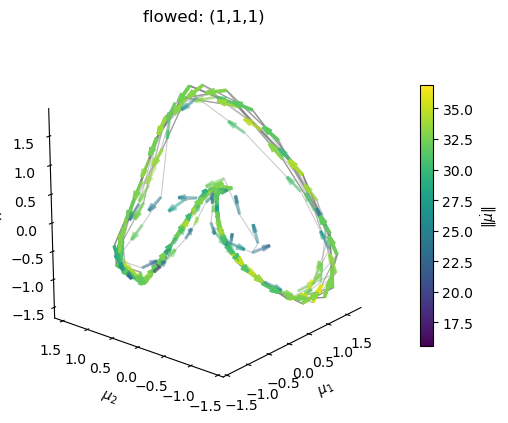

In [33]:
fig, ax = plot_mu_velocity_3d(mu_pts_flow1, v_mu_flow1, trajectories=mu_traj_flow1_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_flow1,
                    title="flowed: (1,1,1)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/3_1_flow_v_3d_111.pdf")
plt.savefig(plotFolder + "/3_1_flow_v_3d_111.png")

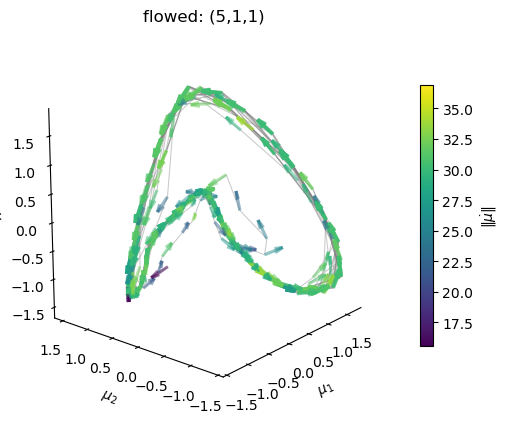

In [34]:
fig, ax = plot_mu_velocity_3d(mu_pts_flow2, v_mu_flow2, trajectories=mu_traj_flow2_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_flow2,
                    title="flowed: (5,1,1)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/3_2_flow_v_3d_511.pdf")
plt.savefig(plotFolder + "/3_2_flow_v_3d_511.png")

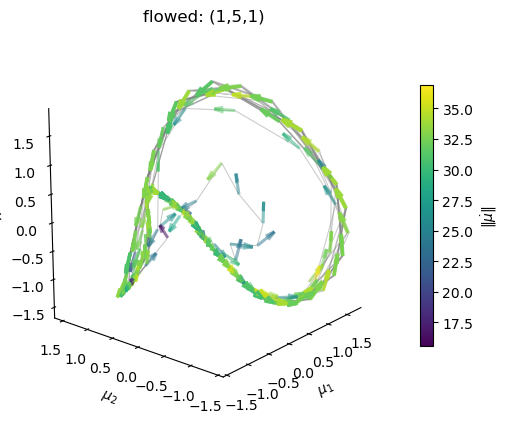

In [35]:
fig, ax = plot_mu_velocity_3d(mu_pts_flow3, v_mu_flow3, trajectories=mu_traj_flow3_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_flow3,
                    title="flowed: (1,5,1)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/3_3_flow_v_3d_151.pdf")
plt.savefig(plotFolder + "/3_3_flow_v_3d_151.png")

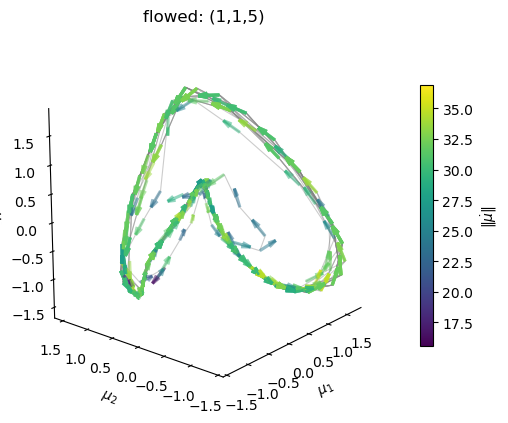

In [36]:
fig, ax = plot_mu_velocity_3d(mu_pts_flow4, v_mu_flow4, trajectories=mu_traj_flow4_np, dims_3d=(0,1,2),
                    speed_color=v_mu_full_flow4,
                    title="flowed: (1,1,5)", figsize=(5, 5), quiver_alpha=0.5,
                              speed_norm=shared_norm)
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
ax.view_init(**view)
plt.savefig(plotFolder + "/3_4_flow_v_3d_115.pdf")
plt.savefig(plotFolder + "/3_4_flow_v_3d_115.png")